In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import itertools

Mounted at /content/drive


In [2]:
dataset_path = "/content/drive/MyDrive/Liver Biopsies"
batch_size = 32
seed = 123
val_split = 0.20
img_size = (299,299)

In [3]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='categorical',
    validation_split=val_split,
    subset='training',
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    interpolation="bilinear",   # avoids some read issues
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='categorical',
    validation_split=val_split,
    subset='validation',
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    interpolation="bilinear",
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 3856 files belonging to 5 classes.
Using 3085 files for training.
Found 3856 files belonging to 5 classes.
Using 771 files for validation.


In [4]:
base = InceptionV3(weights='imagenet', include_top=False, input_shape=img_size + (3,))
base.trainable = False   # freeze backbone

inputs = layers.Input(shape=img_size + (3,))
x = preprocess_input(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,854,437 (87.18 MB)

 Trainable params: 1,051,653 (4.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 774s 8s/step - accuracy: 0.5356 - loss: 1.1442 - val_accuracy: 0.8755 - val_loss: 0.4159
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.8652 - loss: 0.4267 - val_accuracy: 0.8988 - val_loss: 0.3412
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - accuracy: 0.8900 - loss: 0.3269 - val_accuracy: 0.9079 - val_loss: 0.3023
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - accuracy: 0.9090 - loss: 0.2944 - val_accuracy: 0.9131 - val_loss: 0.2916
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.9083 - loss: 0.2744 - val_accuracy: 0.9131 - val_loss: 0.2712
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.9161 - loss: 0.2440 - val_accuracy: 0.9222 - val_loss: 0.2617
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 132ms/step - accuracy: 0.9199 - loss: 0.2209 - val_accuracy: 0.9209 - val_loss: 0.2595
Epoch 8/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.9306 - loss: 0.2048 - val_accura

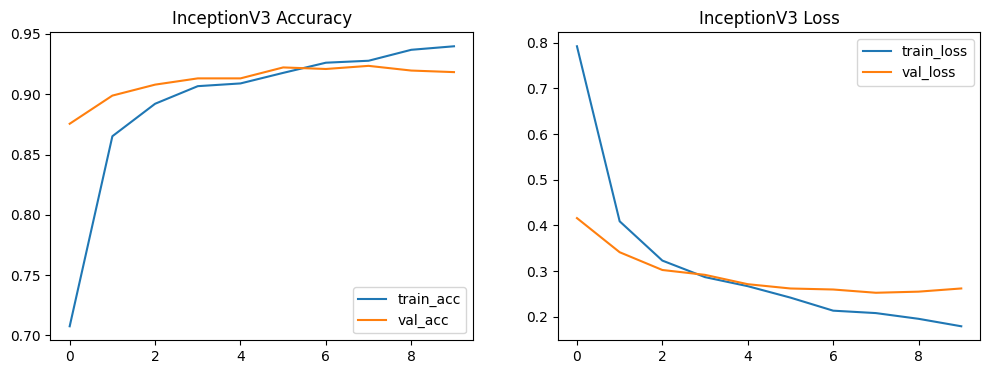

In [6]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('InceptionV3 Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('InceptionV3 Loss')
plt.show()

In [7]:
y_true, y_pred, y_prob = [], [], []
for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true.append(np.argmax(y_batch, axis=1))
    y_pred.append(np.argmax(preds, axis=1))
    y_prob.append(preds)

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_prob = np.concatenate(y_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [8]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

              precision    recall  f1-score   support

  Ballooning     0.9296    0.8462    0.8859       156
    Fibrosis     0.9730    1.0000    0.9863       144
     Healthy     0.8408    0.9103    0.8742       145
Inflammation     0.8917    0.8537    0.8723       164
   Steatosis     0.9581    0.9877    0.9726       162

    accuracy                         0.9183       771
   macro avg     0.9186    0.9196    0.9183       771
weighted avg     0.9189    0.9183    0.9178       771



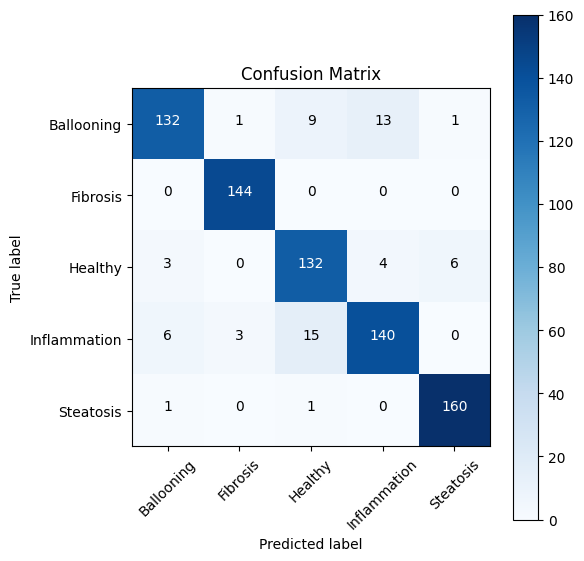

In [9]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

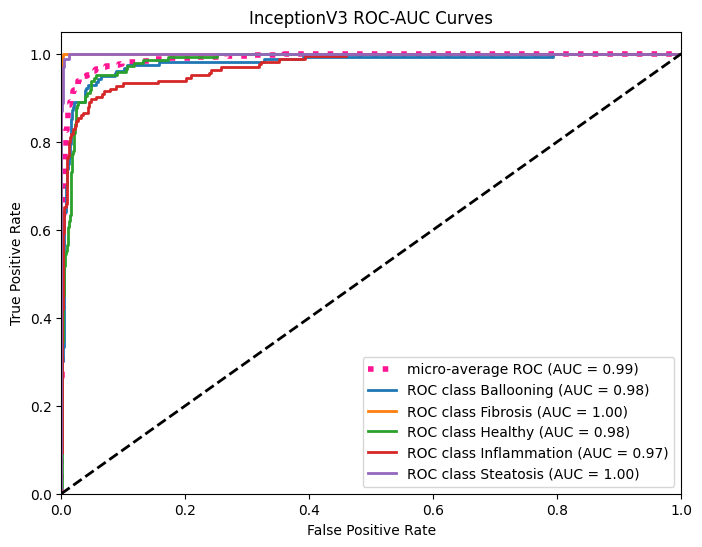

In [12]:
from sklearn.preprocessing import label_binarize
n_classes = num_classes
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC (AUC = {0:0.2f})'.format(roc_auc["micro"]),
         color='deeppink', linestyle=':', linewidth=4)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label='ROC class {0} (AUC = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('InceptionV3 ROC-AUC Curves')
plt.legend(loc="lower right")
plt.show()

In [14]:
print(f"\nFinal Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")


Final Training Accuracy: 93.97%
Final Validation Accuracy: 91.83%
